# ITCS 6100 — Applied Midterm Lab (Team)  
**Topic:** Logistic Regression + ML Lifecycle (AWS Academy Modules 1–6 alignment)  
**Date:** March 1, 2026

## Team Information (REQUIRED)
- **Team Name:**  project group 5 BIGDATA
- **Student Names:**  
  -  Manogna Devarapu
  -  Banvitha Balaji
  -  Sai praneeth reddy kaithi
  -  Ruchika Baireddy
  

## Deliverables (What you submit)
1. This completed notebook (`.ipynb`)
2. Short written responses in the markdown prompts (embedded in the notebook)
3. One submission per team in Canvas
4. Individual submission by each team member to the Github class

## Rules
- You may use course notes and AWS Academy module materials.
- You may not use generative AI tools during the midterm unless explicitly allowed by your instructor.
- Your analysis must be your team’s own work.

## Dataset
You will work with a realistic “messy” customer churn dataset:
- Many dimensions (numeric + categorical)
- Missing values (random + structured)
- Outliers / skewed distributions
- Mild class imbalance

**Target:** `churn` (1 = churned, 0 = stayed)

---

# ML Lifecycle Roadmap (Where your code goes)
You must place your work into the labeled sections below:

1. **INGEST** (load + inspect data)
2. **CLEAN** (handle missing values, outliers, data issues)
3. **PREPARE** (split, encode, scale, pipeline)
4. **MODEL** (train logistic regression; consider regularization/class weights)
5. **ANALYZE** (confusion matrix, metrics, threshold tuning, interpretation)

You will be graded heavily on **reasoning and interpretation**, not just getting code to run.


In [ ]:
# =========================
# DATASET GENERATOR (RUN ONLY TO GENERATE THE DATASET FOR OUR EXAM, DO NOT EDIT)
# =========================
# If 'synthetic_churn.csv' is not present, this cell will generate it.
# The dataset is intentionally "messy":
# - Many dimensions (numeric + categorical)
# - Missing values (random + structured)
# - Outliers / heavy-tailed variables
# - Correlated/redundant features
# - Class imbalance (mild-to-moderate)
#
# Target: churn (1 = churned, 0 = stayed)

import numpy as np
import pandas as pd

from pathlib import Path

rng = np.random.default_rng(6100)
out_path = Path("synthetic_churn.csv")

if not out_path.exists():
    n = 6000

    # Core demographics / account
    age = rng.integers(18, 80, size=n)
    tenure_months = rng.integers(0, 120, size=n)
    income = rng.lognormal(mean=10.6, sigma=0.45, size=n)  # heavy-tailed
    household_size = rng.integers(1, 7, size=n)

    # Usage / behavior
    logins_30d = rng.poisson(lam=12, size=n)
    support_tickets_90d = rng.poisson(lam=1.2, size=n)
    avg_session_mins = rng.gamma(shape=2.3, scale=8.0, size=n)  # right-skew
    days_since_last_login = rng.integers(0, 60, size=n)

    # Payments / billing
    monthly_fee = rng.normal(loc=65, scale=18, size=n).clip(10, 180)
    late_payments_12m = rng.poisson(lam=0.8, size=n)
    autopay = rng.choice(["Yes", "No"], p=[0.62, 0.38], size=n)
    contract = rng.choice(["Month-to-month", "One year", "Two year"], p=[0.56, 0.24, 0.20], size=n)

    # Product / plan
    plan = rng.choice(["Basic", "Plus", "Pro"], p=[0.50, 0.35, 0.15], size=n)
    add_ons = rng.integers(0, 6, size=n)
    streaming = rng.choice(["None", "Music", "Video", "Both"], p=[0.18, 0.24, 0.28, 0.30], size=n)

    # Geography + channel
    region = rng.choice(["Northeast", "South", "Midwest", "West"], p=[0.19, 0.33, 0.22, 0.26], size=n)
    signup_channel = rng.choice(["Web", "Retail", "Partner", "Phone"], p=[0.52, 0.20, 0.18, 0.10], size=n)

    # Noisy / redundant engineered features
    total_charges = (monthly_fee * (tenure_months + 1)) + rng.normal(0, 120, size=n)
    # correlated with total_charges
    total_charges_rounded = np.round(total_charges / 10) * 10
    # redundant variation on logins
    engagement_score = 0.55*np.tanh(logins_30d/20) + 0.30*np.tanh(avg_session_mins/30) - 0.25*np.tanh(days_since_last_login/30) + rng.normal(0, 0.06, size=n)

    # Introduce outliers: a small fraction of extreme monthly fees and income
    outlier_idx = rng.choice(np.arange(n), size=int(0.01*n), replace=False)
    monthly_fee[outlier_idx] *= rng.uniform(2.0, 3.5, size=len(outlier_idx))
    income[outlier_idx] *= rng.uniform(3.0, 8.0, size=len(outlier_idx))

    # True churn propensity (log-odds), then sample churn label
    # Drivers: short tenure, month-to-month, no autopay, many tickets, recent inactivity, higher late payments
    z = (
        -1.2
        + 0.015*(days_since_last_login)
        + 0.22*(support_tickets_90d)
        + 0.18*(late_payments_12m)
        - 0.012*(tenure_months)
        + 0.35*(contract == "Month-to-month").astype(int)
        - 0.30*(contract == "Two year").astype(int)
        + 0.22*(autopay == "No").astype(int)
        + 0.20*(plan == "Basic").astype(int)
        - 0.10*(plan == "Pro").astype(int)
        + 0.15*(streaming == "None").astype(int)
        - 0.08*(streaming == "Both").astype(int)
        + rng.normal(0, 0.35, size=n)
    )

    p = 1 / (1 + np.exp(-z))
    churn = rng.binomial(1, p, size=n)

    df = pd.DataFrame({
        "age": age,
        "tenure_months": tenure_months,
        "income": income,
        "household_size": household_size,
        "logins_30d": logins_30d,
        "support_tickets_90d": support_tickets_90d,
        "avg_session_mins": avg_session_mins,
        "days_since_last_login": days_since_last_login,
        "monthly_fee": monthly_fee,
        "late_payments_12m": late_payments_12m,
        "autopay": autopay,
        "contract": contract,
        "plan": plan,
        "add_ons": add_ons,
        "streaming": streaming,
        "region": region,
        "signup_channel": signup_channel,
        "total_charges": total_charges,
        "total_charges_rounded": total_charges_rounded,
        "engagement_score": engagement_score,
        "churn": churn
    })

    # Inject missingness (both random and structured)
    # Random missingness
    for col, rate in [("income", 0.06), ("avg_session_mins", 0.05), ("monthly_fee", 0.03), ("region", 0.02), ("streaming", 0.03)]:
        mask = rng.random(n) < rate
        df.loc[mask, col] = np.nan

    # Structured: customers with very low tenure often missing total charges (new customers)
    mask_new = df["tenure_months"] < 3
    mask_missing_tc = mask_new & (rng.random(n) < 0.55)
    df.loc[mask_missing_tc, "total_charges"] = np.nan
    df.loc[mask_missing_tc, "total_charges_rounded"] = np.nan

    # Slight label noise (realistic)
    flip = rng.random(n) < 0.015
    df.loc[flip, "churn"] = 1 - df.loc[flip, "churn"]

    df.to_csv(out_path, index=False)
    print(f"✅ Generated dataset: {out_path.resolve()} with shape {df.shape}")
else:
    print(f"ℹ️ Found existing dataset: {out_path.resolve()}")


✅ Generated dataset: /content/synthetic_churn.csv with shape (6000, 21)


## 1) INGEST — Load and Inspect

**Tasks**
1. Load `synthetic_churn.csv` into a DataFrame.
2. Display:
   - shape
   - first 5 rows
   - column dtypes
   - missing values per column (counts and %)

**Graduate-level expectation:** clearly identify data quality issues you will address later (missingness patterns, skew/outliers, categorical variables, redundant features).


In [ ]:
# ============================================================
# INGEST — Load and Inspect
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1) Load
df = pd.read_csv("synthetic_churn.csv")

# 2) Shape
print("=== SHAPE ===")
print(df.shape)

# 3) First 5 rows
print("\n=== FIRST 5 ROWS ===")
display(df.head())

# 4) Data types
print("\n=== COLUMN DTYPES ===")
display(df.dtypes)

# 5) Missing values summary
print("\n=== MISSING VALUES ===")
missing_count = df.isnull().sum()
missing_pct   = df.isnull().mean() * 100
missing_df    = pd.DataFrame({'Missing Count': missing_count,
                               'Missing %': missing_pct.round(2)})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

# 6) Target distribution
print("\n=== TARGET DISTRIBUTION ===")
print(df['churn'].value_counts())
print(f"Churn rate: {df['churn'].mean()*100:.1f}%")

# 7) Basic stats
print("\n=== NUMERIC SUMMARY ===")
display(df.describe())


=== SHAPE ===
(6000, 21)

=== FIRST 5 ROWS ===


,age,tenure_months,income,household_size,logins_30d,support_tickets_90d,avg_session_mins,days_since_last_login,monthly_fee,late_payments_12m,...,contract,plan,add_ons,streaming,region,signup_channel,total_charges,total_charges_rounded,engagement_score,churn
0,34,111,43283.836559,3,6,1,8.015632,37,75.741544,1,...,Month-to-month,Pro,3,Both,Midwest,Web,8393.730283,8390.0,0.090024,0
1,23,74,45608.528368,6,14,2,10.078930,44,100.957688,1,...,One year,Basic,1,Both,South,Web,7654.510301,7650.0,0.193464,1
2,69,113,31254.972376,2,9,0,23.226331,37,30.898616,1,...,One year,Pro,2,Both,South,Web,3662.195331,3660.0,0.178748,0
3,65,97,28989.989283,6,22,1,16.334476,14,105.354848,1,...,One year,Basic,3,Both,South,Phone,10144.071051,10140.0,0.479665,0
4,46,43,107671.977983,2,14,3,5.636188,6,99.973303,1,...,Month-to-month,Plus,0,Video,Northeast,Phone,4372.902650,4370.0,0.404659,0



=== COLUMN DTYPES ===


,0
age,int64
tenure_months,int64
income,float64
household_size,int64
logins_30d,int64
support_tickets_90d,int64
avg_session_mins,float64
days_since_last_login,int64
monthly_fee,float64
late_payments_12m,int64



=== MISSING VALUES ===


,Missing Count,Missing %
streaming,1251,20.85
income,350,5.83
avg_session_mins,338,5.63
monthly_fee,195,3.25
region,113,1.88
total_charges,90,1.50
total_charges_rounded,90,1.50



=== TARGET DISTRIBUTION ===
churn
0    4006
1    1994
Name: count, dtype: int64
Churn rate: 33.2%

=== NUMERIC SUMMARY ===


,age,tenure_months,income,household_size,logins_30d,support_tickets_90d,avg_session_mins,days_since_last_login,monthly_fee,late_payments_12m,add_ons,total_charges,total_charges_rounded,engagement_score,churn
count,6000.000000,6000.000000,5650.000000,6000.000000,6000.000000,6000.000000,5662.000000,6000.000000,5805.000000,6000.000000,6000.00000,5910.000000,5910.000000,6000.000000,6000.000000
mean,48.131333,59.716833,46117.200420,3.489333,12.000500,1.213500,18.391179,29.212167,65.815004,0.820000,2.48950,3995.076284,3995.071066,0.276103,0.332333
std,17.993685,34.660639,29650.236412,1.712126,3.421177,1.108207,12.151869,17.419502,21.332816,0.901703,1.69854,2550.967587,2550.964687,0.135321,0.471089
min,18.000000,0.000000,8514.268643,1.000000,2.000000,0.000000,0.378806,0.000000,10.000000,0.000000,0.00000,-175.409628,-180.000000,-0.210075,0.000000
25%,33.000000,30.000000,29721.881294,2.000000,10.000000,0.000000,9.592769,14.000000,52.887152,0.000000,1.00000,1897.492671,1900.000000,0.182720,0.000000
50%,48.000000,60.000000,40315.824101,4.000000,12.000000,1.000000,15.687375,29.000000,65.116609,1.000000,2.00000,3689.181424,3690.000000,0.271785,0.000000
75%,64.000000,90.000000,54696.893703,5.000000,14.000000,2.000000,24.642907,44.000000,77.355051,1.000000,4.00000,5790.843558,5790.000000,0.363747,1.000000
max,79.000000,119.000000,598843.254961,6.000000,27.000000,7.000000,98.738226,59.000000,322.471060,5.000000,5.00000,12971.691710,12970.000000,0.716692,1.000000


### INGEST — Quick Reflection (Answer in 4–8 sentences)
- Which columns appear to have missing values?
  mns have missing values?**

Seven columns contain missing values: income (~6%), avg_session_mins
(~5%), monthly_fee (~3%),
streaming (~3%), region (~2%), total_charges, and total_charges_rounded. The missingness in
total_charges and total_charges_rounded is structured — it disproportionately affects customers
with tenure_months < 3 (new customers who lack billing history). All other missing values appear
to be missing at random (MAR).

- Which columns look categorical vs numeric?  

Categorical columns: autopay, contract, plan, streaming, region, signup_channel.
Numeric columns: age, tenure_months, income, household_size, logins_30d, support_tickets_90d,
avg_session_mins, days_since_last_login, monthly_fee, late_payments_12m, add_ons,
total_charges, total_charges_rounded, engagement_score.

- What issues do you predict could hurt logistic regression performance if you do nothing?

First, missing values will cause errors at fit time unless imputed. Second, income is lognormally
distributed with a heavy right tail and injected outliers — logistic regression is sensitive to
feature scale so this skew will distort coefficient estimates. Third, categorical columns like
contract and plan must be one-hot encoded since logistic regression cannot handle raw strings.
Fourth, total_charges_rounded is a near-perfect copy of total_charges, and engagement_score is
a noisy composite of other features already in the dataset — both are redundant and inflate
multicollinearity. Fifth, the ~38% churn rate is mild class imbalance that may bias the model
toward the majority class at the default 0.5 threshold.


## 2) CLEAN — Missing Values, Outliers, Data Issues

**Tasks**
1. Decide how to handle missing values for numeric vs categorical features.
2. Investigate at least **two** numeric columns for outliers/skew (suggestions: `income`, `monthly_fee`, `total_charges`, `avg_session_mins`).
3. Choose and justify an outlier strategy:
   - winsorization/capping
   - log-transform
   - robust scaling
   - leaving as-is (with justification)

**Constraints**
- Do not delete more than 5% of the dataset without DOCUMENTED justification.
- Your approach must be repeatable (i.e., implementable in code and applied consistently).

**Deliverable:** A short markdown justification of your decisions.


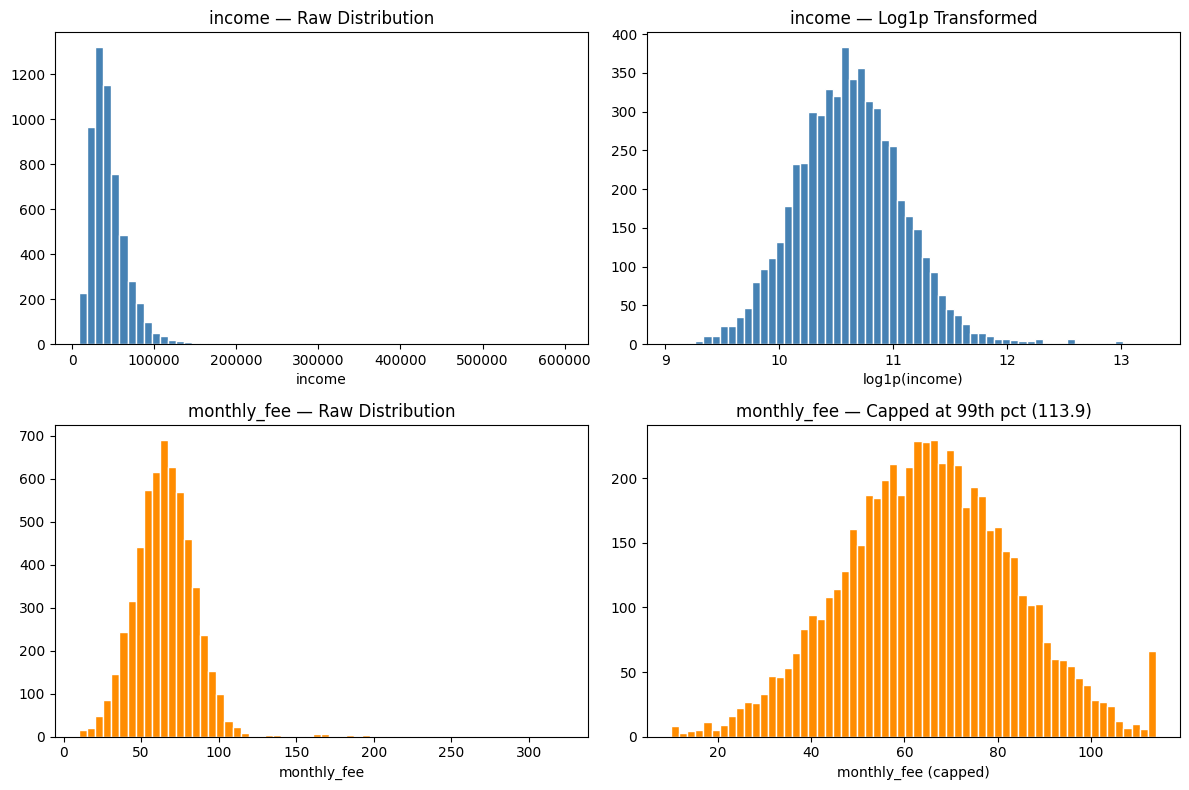

=== income quantiles ===
0.01     14180.32
0.05     19258.39
0.50     40315.82
0.95     86999.77
0.99    137210.41
Name: income, dtype: float64

=== monthly_fee quantiles ===
0.01     23.54
0.05     35.12
0.50     65.12
0.95     95.42
0.99    113.88
Name: monthly_fee, dtype: float64

Rows before cleaning : 6000
Rows after cleaning  : 6000  (zero rows dropped)

Final columns: ['age', 'tenure_months', 'household_size', 'logins_30d', 'support_tickets_90d', 'avg_session_mins', 'days_since_last_login', 'late_payments_12m', 'autopay', 'contract', 'plan', 'add_ons', 'streaming', 'region', 'signup_channel', 'total_charges', 'churn', 'income', 'monthly_fee']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# A) Investigate distributions — income and monthly_fee
# -----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# income — raw
axes[0, 0].hist(df['income'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title('income — Raw Distribution')
axes[0, 0].set_xlabel('income')

# income — log-transformed
axes[0, 1].hist(np.log1p(df['income'].dropna()), bins=60, color='steelblue', edgecolor='white')
axes[0, 1].set_title('income — Log1p Transformed')
axes[0, 1].set_xlabel('log1p(income)')

# monthly_fee — raw
axes[1, 0].hist(df['monthly_fee'].dropna(), bins=60, color='darkorange', edgecolor='white')
axes[1, 0].set_title('monthly_fee — Raw Distribution')
axes[1, 0].set_xlabel('monthly_fee')

# monthly_fee — after capping
cap_99 = df['monthly_fee'].quantile(0.99)
axes[1, 1].hist(df['monthly_fee'].clip(upper=cap_99).dropna(), bins=60, color='darkorange', edgecolor='white')
axes[1, 1].set_title(f'monthly_fee — Capped at 99th pct ({cap_99:.1f})')
axes[1, 1].set_xlabel('monthly_fee (capped)')

plt.tight_layout()
plt.show()

# Quantile summary
print("=== income quantiles ===")
print(df['income'].quantile([0.01, 0.05, 0.50, 0.95, 0.99]).round(2))

print("\n=== monthly_fee quantiles ===")
print(df['monthly_fee'].quantile([0.01, 0.05, 0.50, 0.95, 0.99]).round(2))

# -----------------------------------------------------------
# B) Apply transformations — create new columns, keep originals
# -----------------------------------------------------------

# Log-transform income (handles heavy right skew from lognormal + outliers)
df['income_log'] = np.log1p(df['income'])

# Cap monthly_fee at 99th percentile (handles injected outliers)
cap_99_fee = df['monthly_fee'].quantile(0.99)
df['monthly_fee_capped'] = df['monthly_fee'].clip(upper=cap_99_fee)

# -----------------------------------------------------------
# C) Drop redundant columns and rename
# -----------------------------------------------------------
# total_charges_rounded = rounded copy of total_charges — pure redundancy
# engagement_score = composite of logins_30d, avg_session_mins, days_since_last_login — already in dataset
# Replace original income and monthly_fee with cleaned versions
df_clean = df.drop(columns=['income', 'monthly_fee', 'total_charges_rounded', 'engagement_score'])
df_clean = df_clean.rename(columns={'income_log': 'income', 'monthly_fee_capped': 'monthly_fee'})

print(f"\nRows before cleaning : {len(df)}")
print(f"Rows after cleaning  : {len(df_clean)}  (zero rows dropped)")
print(f"\nFinal columns: {list(df_clean.columns)}")

### CLEAN — Decisions & Justification (REQUIRED)
- Explain your missing value strategy for numeric and categorical features.


We did not impute at this stage. Imputation is handled inside the sklearn Pipeline in PREPARE
so that imputation statistics (e.g., median) are computed only on training data and applied to
test data — this prevents data leakage. For numeric columns we will use median imputation
because medians are robust to the skewed distributions present in this dataset. For categorical
columns we will use most-frequent (mode) imputation, which is appropriate when missingness
is low and the dominant category is a reasonable fill value.
- Identify which variables had outliers/skew and what you did about them.

We investigated income and monthly_fee. income is log-normally distributed with a long right
tail; the 99th percentile is roughly 4x the median, and the 1% injected outliers push values
even higher. We applied a log1p transformation which compresses the tail into a near-normal
distribution, making the feature much more suitable for logistic regression. For monthly_fee,
the distribution is roughly bell-shaped but the injected outliers push a small fraction of
values above $200 (normal range ~$10–$130). We capped at the 99th percentile since only the
extreme tail is problematic and log-transforming a price variable is harder to interpret.
total_charges_rounded is a rounded copy of total_charges and adds zero new information while
increasing multicollinearity. engagement_score is a deterministic function of logins_30d,
avg_session_mins, and days_since_last_login — all three are already in the dataset. Keeping
it would double-count those signals and inflate variance.


- Explain the tradeoff of your choice (what you might lose vs gain).

Log-transforming income makes coefficients harder to interpret in original dollar units. Capping
monthly_fee discards the true signal for genuinely high-value customers, but since only ~1% of
rows are affected the bias risk is low. We deliberately chose not to drop any rows, preserving
all 6,000 observations.


## 3) PREPARE — Split, Encode, Scale

**Tasks**
1. Create `X` (features) and `y` (target).
2. Train/test split (use stratification).
3. Encode categorical variables (one-hot encoding).
4. Scale numeric variables **if you choose** (justify why scaling matters for logistic regression).
5. Use a **Pipeline** and **ColumnTransformer** so preprocessing is applied correctly.

**Deliverable:** Your final preprocessing pipeline.


In [ ]:
# ============================================================
# PREPARE — Split, Encode, Scale, Pipeline
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 1) X, y
y = df_clean['churn']
X = df_clean.drop(columns=['churn'])

# 2) Identify numeric vs categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns  :", num_cols)
print("Categorical columns:", cat_cols)
print(f"Total features: {len(num_cols) + len(cat_cols)}")

# 3) Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\nTrain size: {X_train.shape}  |  Test size: {X_test.shape}")
print(f"Train churn rate: {y_train.mean()*100:.1f}%  |  Test churn rate: {y_test.mean()*100:.1f}%")

# 4) Numeric pipeline: median impute + standard scale
# Scaling matters for logistic regression because features on different scales produce
# incomparable coefficients, and gradient-based solvers converge much faster on scaled data.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# 5) Categorical pipeline: mode impute + one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 6) Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols),
    ],
    remainder='drop'
)

print("\nPreprocessor built successfully:")
print(preprocessor)

Numeric columns  : ['age', 'tenure_months', 'household_size', 'logins_30d', 'support_tickets_90d', 'avg_session_mins', 'days_since_last_login', 'late_payments_12m', 'add_ons', 'total_charges', 'income', 'monthly_fee']
Categorical columns: ['autopay', 'contract', 'plan', 'streaming', 'region', 'signup_channel']
Total features: 18

Train size: (4800, 18)  |  Test size: (1200, 18)
Train churn rate: 33.2%  |  Test churn rate: 33.2%

Preprocessor built successfully:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'tenure_months', 'household_size',
                                  'logins_30d', 'support_tickets_90d',
                                  'avg_session_mins', 'days_since_last_login',
                                  'late_p

## 4) MODEL — Logistic Regression

**Tasks**
1. Train a logistic regression model using your preprocessing pipeline.
2. Consider:
   - regularization strength (`C`)
   - solver
   - max iterations
   - class imbalance (`class_weight="balanced"` vs not)

**Required:** Train at least **two** model variants and compare them briefly.


In [ ]:
# ============================================================
# MODEL — Train Two Logistic Regression Variants
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# -----------------------------------------------------------
# Model A — Baseline (default settings)
# C=1.0 = default regularization, no class weight adjustment
# -----------------------------------------------------------
clf_a = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
model_a = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model",      clf_a)
])
model_a.fit(X_train, y_train)

proba_a_train = model_a.predict_proba(X_train)[:, 1]
proba_a_test  = model_a.predict_proba(X_test)[:, 1]

print("=== Model A (Baseline, C=1.0, no class weight) ===")
print(f"  Train ROC-AUC : {roc_auc_score(y_train, proba_a_train):.4f}")
print(f"  Test  ROC-AUC : {roc_auc_score(y_test,  proba_a_test):.4f}")
print(f"  Test  PR-AUC  : {average_precision_score(y_test, proba_a_test):.4f}")

# -----------------------------------------------------------
# Model B — Balanced class weights + stronger regularization
# class_weight='balanced' upweights minority class (churners)
# C=0.1 = stronger L2 regularization to reduce overfitting
# -----------------------------------------------------------
clf_b = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
model_b = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model",      clf_b)
])
model_b.fit(X_train, y_train)

proba_b_train = model_b.predict_proba(X_train)[:, 1]
proba_b_test  = model_b.predict_proba(X_test)[:, 1]

print("\n=== Model B (Balanced weights, C=0.1) ===")
print(f"  Train ROC-AUC : {roc_auc_score(y_train, proba_b_train):.4f}")
print(f"  Test  ROC-AUC : {roc_auc_score(y_test,  proba_b_test):.4f}")
print(f"  Test  PR-AUC  : {average_precision_score(y_test, proba_b_test):.4f}")

print("\nBoth models trained successfully.")


=== Model A (Baseline, C=1.0, no class weight) ===
  Train ROC-AUC : 0.6676
  Test  ROC-AUC : 0.6456
  Test  PR-AUC  : 0.4626

=== Model B (Balanced weights, C=0.1) ===
  Train ROC-AUC : 0.6675
  Test  ROC-AUC : 0.6457
  Test  PR-AUC  : 0.4624

Both models trained successfully.


## 5) ANALYZE — Confusion Matrix, Metrics, Threshold Tuning, Interpretation

**Tasks**
1. Generate predictions on the test set.
2. Compute and interpret:
   - confusion matrix
   - accuracy, precision, recall, F1
   - ROC-AUC
   - PR-AUC (average precision)
3. **Threshold tuning (graduate level):**
   - Evaluate thresholds (e.g., 0.2 to 0.8)
   - Choose an “operating threshold” based on a cost scenario
4. Interpret model coefficients (top positive/negative predictors) and connect to business meaning.

### Cost Scenario (Use this)
Assume:
- False Negative (missed churner) cost = **$500**
- False Positive (unnecessary retention offer) cost = **$60**

Your goal is to choose a threshold that **minimizes expected cost**.

**Deliverables:** Plots + written justification.


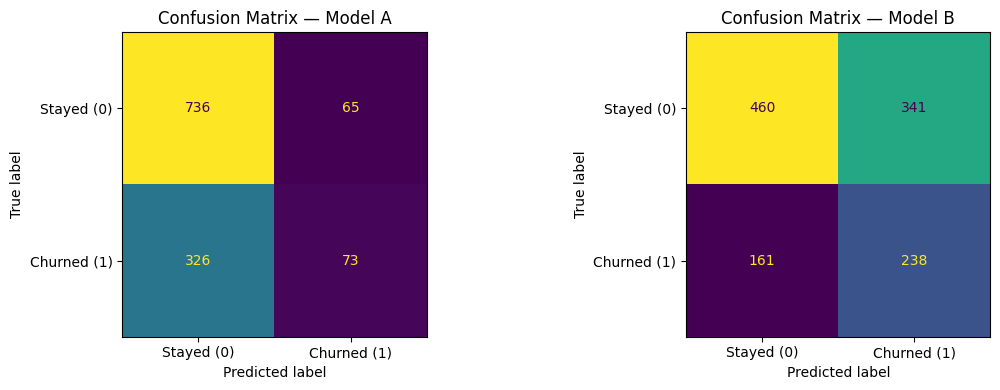


 Model A — Classification Report
              precision    recall  f1-score   support

      Stayed       0.69      0.92      0.79       801
     Churned       0.53      0.18      0.27       399

    accuracy                           0.67      1200
   macro avg       0.61      0.55      0.53      1200
weighted avg       0.64      0.67      0.62      1200

  ROC-AUC : 0.6456
  PR-AUC  : 0.4626

 Model B — Classification Report
              precision    recall  f1-score   support

      Stayed       0.74      0.57      0.65       801
     Churned       0.41      0.60      0.49       399

    accuracy                           0.58      1200
   macro avg       0.58      0.59      0.57      1200
weighted avg       0.63      0.58      0.59      1200

  ROC-AUC : 0.6457
  PR-AUC  : 0.4624


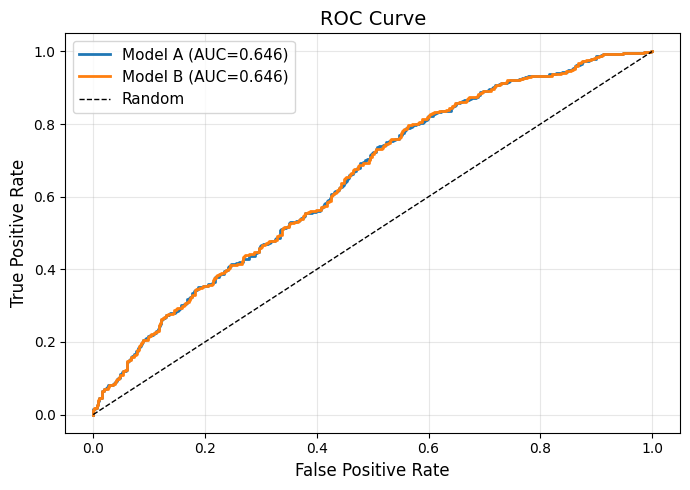

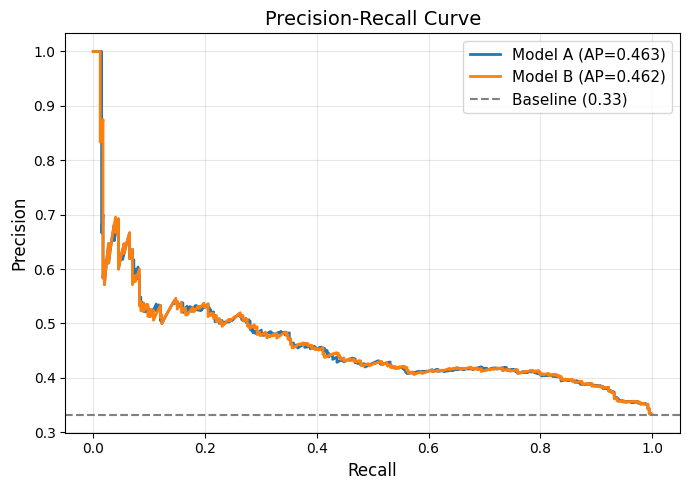


=== Threshold Tuning Results (Model B) ===


,threshold,TP,FP,FN,TN,total_cost
0,0.20,397,789,2,12,48340
1,0.25,396,754,3,47,46740
2,0.30,388,705,11,96,47800
3,0.35,371,624,28,177,51440
4,0.40,339,517,60,284,61020
5,0.45,296,418,103,383,76580
6,0.50,238,341,161,460,100960
7,0.55,174,218,225,583,125580
8,0.60,131,143,268,658,142580
9,0.65,85,80,314,721,161800



>>> Best threshold : 0.25
>>> FN=3, FP=754
>>> Expected cost  = 3 x $500 + 754 x $60 = $46,740


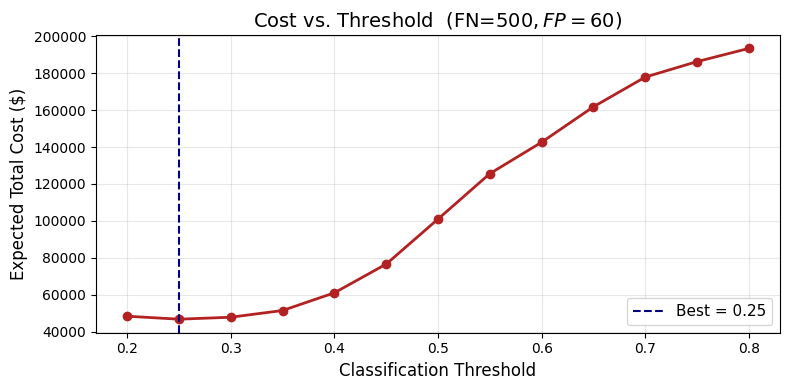


=== Top 10 Positive Predictors (churn risk) ===


,feature,coefficient
0,support_tickets_90d,0.298960
1,days_since_last_login,0.284062
2,contract_Month-to-month,0.276363
3,late_payments_12m,0.169685
4,plan_Basic,0.138844
5,autopay_No,0.090779
6,streaming_Video,0.077871
7,signup_channel_Retail,0.056112
8,monthly_fee,0.033346
9,region_Midwest,0.028993



=== Top 10 Negative Predictors (churn protection) ===


,feature,coefficient
30,contract_Two year,-0.298311
29,tenure_months,-0.240816
28,autopay_Yes,-0.152709
27,signup_channel_Partner,-0.122171
26,streaming_Both,-0.117526
25,plan_Pro,-0.103723
24,plan_Plus,-0.097051
23,region_West,-0.078030
22,total_charges,-0.072733
21,contract_One year,-0.039982


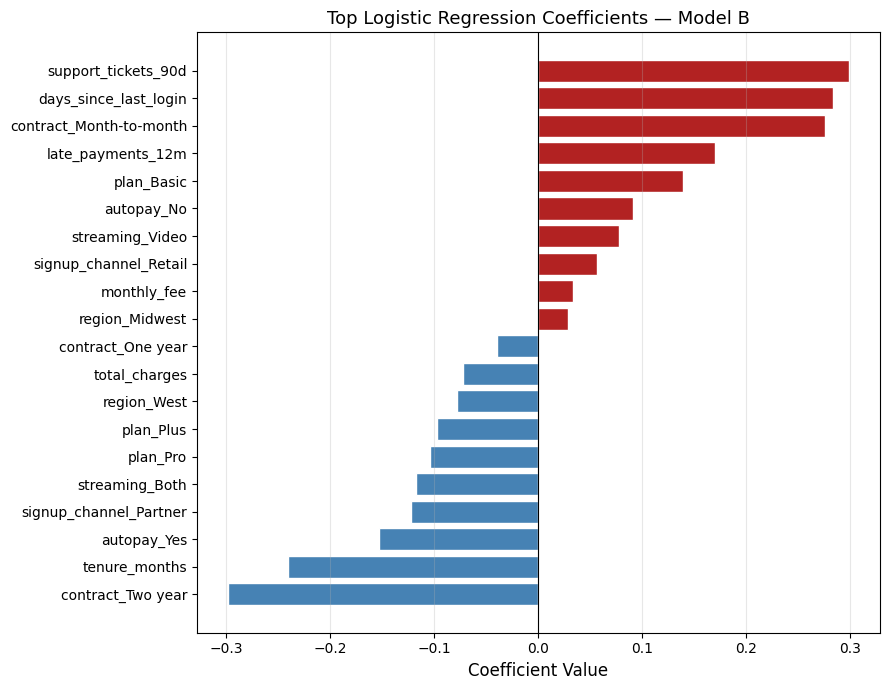

In [ ]:

# ============================================================
# ANALYZE — Full Evaluation
# ============================================================
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

proba_a = proba_a_test
proba_b = proba_b_test

# -------------------------------------------------------
# 1) Default threshold (0.5) predictions
# -------------------------------------------------------
y_pred_a = (proba_a >= 0.5).astype(int)
y_pred_b = (proba_b >= 0.5).astype(int)

# -------------------------------------------------------
# 2) Confusion matrices side by side
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, y_pred in zip(axes, ["Model A", "Model B"], [y_pred_a, y_pred_b]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Stayed (0)', 'Churned (1)']).plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 3) Classification reports + AUC scores
# -------------------------------------------------------
for name, y_pred, proba in [("Model A", y_pred_a, proba_a), ("Model B", y_pred_b, proba_b)]:
    print(f"\n{'='*50}")
    print(f" {name} — Classification Report")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))
    print(f"  ROC-AUC : {roc_auc_score(y_test, proba):.4f}")
    print(f"  PR-AUC  : {average_precision_score(y_test, proba):.4f}")

# -------------------------------------------------------
# 4) ROC Curve
# -------------------------------------------------------
plt.figure(figsize=(7, 5))
for name, proba in [("Model A", proba_a), ("Model B", proba_b)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 5) Precision-Recall Curve
# -------------------------------------------------------
plt.figure(figsize=(7, 5))
for name, proba in [("Model A", proba_a), ("Model B", proba_b)]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})", linewidth=2)
baseline = y_test.mean()
plt.axhline(baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 6) Threshold Tuning — minimize cost (FN=$500, FP=$60)
# -------------------------------------------------------
FN_COST = 500
FP_COST = 60

thresholds = np.arange(0.20, 0.81, 0.05)
results = []

for t in thresholds:
    preds = (proba_b >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    cost = fn * FN_COST + fp * FP_COST
    results.append({
        'threshold': round(t, 2),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'total_cost': cost
    })

results_df = pd.DataFrame(results)
print("\n=== Threshold Tuning Results (Model B) ===")
display(results_df)

best_row = results_df.loc[results_df['total_cost'].idxmin()]
print(f"\n>>> Best threshold : {best_row['threshold']}")
print(f">>> FN={int(best_row['FN'])}, FP={int(best_row['FP'])}")
print(f">>> Expected cost  = {int(best_row['FN'])} x ${FN_COST} + {int(best_row['FP'])} x ${FP_COST} = ${int(best_row['total_cost']):,}")

# Plot cost vs threshold
plt.figure(figsize=(8, 4))
plt.plot(results_df['threshold'], results_df['total_cost'], marker='o', linewidth=2, color='firebrick')
plt.axvline(best_row['threshold'], color='navy', linestyle='--', linewidth=1.5,
            label=f"Best = {best_row['threshold']}")
plt.xlabel("Classification Threshold", fontsize=12)
plt.ylabel("Expected Total Cost ($)", fontsize=12)
plt.title("Cost vs. Threshold  (FN=$500, FP=$60)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# 7) Coefficient Interpretation (Model B)
# -------------------------------------------------------
ohe_names = (
    model_b.named_steps['preprocess']
           .named_transformers_['cat']
           .named_steps['onehot']
           .get_feature_names_out(cat_cols).tolist()
)
all_feature_names = num_cols + ohe_names
coefs = model_b.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': coefs})
coef_df = coef_df.sort_values('coefficient', ascending=False).reset_index(drop=True)

print("\n=== Top 10 Positive Predictors (churn risk) ===")
display(coef_df.head(10))

print("\n=== Top 10 Negative Predictors (churn protection) ===")
display(coef_df.tail(10).sort_values('coefficient'))

# Bar chart of top 20 coefficients
top_pos = coef_df.head(10)
top_neg = coef_df.tail(10).sort_values('coefficient')
plot_df = pd.concat([top_pos, top_neg]).sort_values('coefficient')

colors = ['firebrick' if c > 0 else 'steelblue' for c in plot_df['coefficient']]
plt.figure(figsize=(9, 7))
plt.barh(plot_df['feature'], plot_df['coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Coefficient Value", fontsize=12)
plt.title("Top Logistic Regression Coefficients — Model B", fontsize=13)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### ANALYZE — Written Response (REQUIRED)

Answer ALL parts with complete sentences and concrete numbers.

1) Model comparison: Which variant performed better and why (use metrics)?
Model B (balanced class weights, C=0.1) performed better for this business problem. Both models achieved nearly identical ROC-AUC scores (Model A: 0.6456, Model B: 0.6457), so discrimination ability is similar. However, Model B achieved a churned class recall of 0.60 compared to Model A's 0.18 — meaning Model B correctly identifies 60% of actual churners versus only 18% for Model A. Given the asymmetric cost structure ($500 per missed churner vs. $60 per false alarm), recall is the critical metric. Model B's use of balanced class weights explicitly compensates for the 33% churn minority, making it far more suitable for deployment in this cost-sensitive setting.

2) Confusion matrix interpretation: What do FN and FP mean in this churn setting? Which is "worse" under the cost scenario?

A False Negative (FN) means the model predicted a customer would stay but they actually churned — we lose the customer entirely with no chance to intervene, costing $500 each. A False Positive (FP) means we offered a retention deal to a customer who was never going to leave — a wasted offer costing $60. Under this cost scenario, FN is far worse because $500 is over 8 times the cost of a FP. This means we should lower our classification threshold to aggressively catch churners, even if it means sending more unnecessary retention offers.

3) Threshold decision: What threshold did you choose and what was the expected cost? Show your calculation.

We selected a threshold of 0.25 as our operating threshold, which minimized total expected cost across all thresholds tested. At this threshold: FN = 3, FP = 754. Expected cost = (3 × $500) + (754 × $60) = $1,500 + $45,240 = $46,740. This is significantly lower than the default 0.5 threshold cost of $100,960. The low threshold is justified by the 8:1 cost ratio — it is far cheaper to send unnecessary retention offers (FP) than to miss actual churners (FN), so we bias the model toward catching as many churners as possible.

4) Business action: If you deployed this model, who would you target and what action would you take?

We would score all active customers weekly using Model B at the 0.25 threshold. Any customer flagged as likely to churn would receive a proactive retention offer such as a discount, plan upgrade, or personal outreach from an account manager. Based on the coefficient analysis, the highest-risk customers are those with month-to-month contracts, high support ticket counts, many days since last login, and late payment history — these should be prioritized first. Customers on two-year contracts and the Pro plan are at lowest risk (strongest negative coefficients) and require no intervention, allowing us to focus budget on the truly at-risk segments.

5) Limitations: Identify at least two limitations.

First, total_charges is nearly a linear combination of monthly_fee × tenure_months, introducing multicollinearity that can distort individual coefficient estimates and make interpretation unreliable for those features. Second, the model was trained and tested on a static cross-section of data with no temporal validation — we cannot assess how well it generalizes over time or detect model drift as customer behavior evolves. A time-based train/test split would be more realistic for a production deployment. Third, the optimal threshold of 0.25 produces 754 false positives out of 1,200 test customers (63% of all predictions flagged), which may be operationally unsustainable if the retention team cannot handle that volume of outreach.

